# Baseline Machine-Failure Models

This notebook prepares the valid model inputs and compares Dummy Classifier, Logistic Regression, and Random Forest on the original AI4I dataset.

## Objectives

- Load data using reusable project code
- Separate valid features and target
- Split data without leakage
- Encode categorical data
- Scale features where required
- Train baseline models
- Evaluate failure detection using suitable metrics

In [6]:
from pathlib import Path
import sys

# Find the main project folder
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

# Allow Python to import files from the project folder
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: c:\Users\aacaa\Documents\reliable-machine-failure-prediction


In [7]:
# Import reusable functions and definitions from data_loader.py
from src.data_loader import (
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    load_ai4i_data,
    create_model_data
)

# Load the complete dataset
data = load_ai4i_data()

# Separate valid inputs and the main target
X, y = create_model_data(data)

print("Dataset loaded through data_loader.py")
print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Input columns:", X.columns.tolist())
print("Target column:", TARGET_COLUMN)

Dataset loaded through data_loader.py
Input shape: (10000, 6)
Target shape: (10000,)
Input columns: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
Target column: Machine failure


## 1. Stratified Data Splitting

The dataset is divided into training, validation, and test sets. Stratification preserves the rare machine-failure percentage in every subset.

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temporary, y_train, y_temporary = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data equally
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temporary,
    y_temporary,
    test_size=0.50,
    random_state=42,
    stratify=y_temporary
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("\nFailure counts:")
print("Training:", y_train.sum())
print("Validation:", y_validation.sum())
print("Test:", y_test.sum())

Training shape: (7000, 6)
Validation shape: (1500, 6)
Test shape: (1500, 6)

Failure counts:
Training: 237
Validation: 51
Test: 51


## 2. Preprocessing Verification

The preprocessing pipeline is fitted only on the training set. The same learned transformations are then applied to validation and test data to prevent leakage.

In [9]:
from src.preprocessing import create_preprocessor

# Create preprocessing with scaling for Logistic Regression
linear_preprocessor = create_preprocessor(
    scale_numeric=True
)

# Learn preprocessing values from training data
X_train_processed = linear_preprocessor.fit_transform(
    X_train
)

# Apply the same preprocessing to unseen data
X_validation_processed = linear_preprocessor.transform(
    X_validation
)

X_test_processed = linear_preprocessor.transform(
    X_test
)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_validation_processed.shape)
print("Processed test shape:", X_test_processed.shape)

print("\nProcessed feature names:")
print(
    linear_preprocessor.get_feature_names_out()
)

Original training shape: (7000, 6)
Processed training shape: (7000, 8)
Processed validation shape: (1500, 8)
Processed test shape: (1500, 8)

Processed feature names:
['numeric__Air temperature' 'numeric__Process temperature'
 'numeric__Rotational speed' 'numeric__Torque' 'numeric__Tool wear'
 'categorical__Type_H' 'categorical__Type_L' 'categorical__Type_M']


## 3. Dummy Classifier Baseline

A majority-class Dummy Classifier establishes the minimum baseline. It predicts no failure for every validation record without learning from the input features.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

# Create a model that always predicts the most common class
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

# Train the dummy model
dummy_model.fit(
    X_train_processed,
    y_train
)

# Produce class predictions for validation data
dummy_predictions = dummy_model.predict(
    X_validation_processed
)

# Produce failure probabilities
dummy_probabilities = dummy_model.predict_proba(
    X_validation_processed
)[:, 1]

# Calculate evaluation metrics
dummy_accuracy = accuracy_score(
    y_validation,
    dummy_predictions
)

dummy_precision = precision_score(
    y_validation,
    dummy_predictions,
    zero_division=0
)

dummy_recall = recall_score(
    y_validation,
    dummy_predictions
)

dummy_f1 = f1_score(
    y_validation,
    dummy_predictions
)

dummy_ap = average_precision_score(
    y_validation,
    dummy_probabilities
)

dummy_confusion_matrix = confusion_matrix(
    y_validation,
    dummy_predictions
)

print(f"Accuracy: {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall: {dummy_recall:.4f}")
print(f"F1-score: {dummy_f1:.4f}")
print(f"Average precision: {dummy_ap:.4f}")

print("\nConfusion matrix:")
print(dummy_confusion_matrix)

Accuracy: 0.9660
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Average precision: 0.0340

Confusion matrix:
[[1449    0]
 [  51    0]]


## 4. Logistic Regression Baseline

Logistic Regression is trained using the scaled and encoded features. The initial model uses the default 0.50 decision threshold without class weighting.

In [11]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train using the processed training data
logistic_model.fit(
    X_train_processed,
    y_train
)

# Produce validation predictions
logistic_predictions = logistic_model.predict(
    X_validation_processed
)

# Obtain the predicted probability of failure
logistic_probabilities = logistic_model.predict_proba(
    X_validation_processed
)[:, 1]

# Calculate validation metrics
logistic_accuracy = accuracy_score(
    y_validation,
    logistic_predictions
)

logistic_precision = precision_score(
    y_validation,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_validation,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_validation,
    logistic_predictions
)

logistic_ap = average_precision_score(
    y_validation,
    logistic_probabilities
)

logistic_confusion_matrix = confusion_matrix(
    y_validation,
    logistic_predictions
)

print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall: {logistic_recall:.4f}")
print(f"F1-score: {logistic_f1:.4f}")
print(f"Average precision: {logistic_ap:.4f}")

print("\nConfusion matrix:")
print(logistic_confusion_matrix)

Accuracy: 0.9680
Precision: 0.6364
Recall: 0.1373
F1-score: 0.2258
Average precision: 0.3844

Confusion matrix:
[[1445    4]
 [  44    7]]


## 5. Random Forest Baseline

An unweighted Random Forest is trained to investigate whether nonlinear relationships and feature interactions improve failure detection.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Create preprocessing without numerical scaling
tree_preprocessor = create_preprocessor(
    scale_numeric=False
)

# Learn preprocessing from training data
X_train_tree = tree_preprocessor.fit_transform(
    X_train
)

# Apply the same preprocessing to validation data
X_validation_tree = tree_preprocessor.transform(
    X_validation
)

# Create the Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train_tree,
    y_train
)

# Produce validation predictions
random_forest_predictions = random_forest_model.predict(
    X_validation_tree
)

# Obtain predicted failure probabilities
random_forest_probabilities = random_forest_model.predict_proba(
    X_validation_tree
)[:, 1]

# Calculate metrics
random_forest_accuracy = accuracy_score(
    y_validation,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_validation,
    random_forest_predictions,
    zero_division=0
)

random_forest_recall = recall_score(
    y_validation,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_validation,
    random_forest_predictions
)

random_forest_ap = average_precision_score(
    y_validation,
    random_forest_probabilities
)

random_forest_confusion_matrix = confusion_matrix(
    y_validation,
    random_forest_predictions
)

print(f"Accuracy: {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall: {random_forest_recall:.4f}")
print(f"F1-score: {random_forest_f1:.4f}")
print(f"Average precision: {random_forest_ap:.4f}")

print("\nConfusion matrix:")
print(random_forest_confusion_matrix)

Accuracy: 0.9800
Precision: 0.8387
Recall: 0.5098
F1-score: 0.6341
Average precision: 0.7349

Confusion matrix:
[[1444    5]
 [  25   26]]


## 6. Baseline Model Comparison

The validation results of the Dummy Classifier, Logistic Regression, and Random Forest are compared using metrics suitable for imbalanced failure prediction.

In [13]:
import pandas as pd

# Combine all model results into one table
baseline_results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        dummy_precision,
        logistic_precision,
        random_forest_precision
    ],
    "Recall": [
        dummy_recall,
        logistic_recall,
        random_forest_recall
    ],
    "F1-score": [
        dummy_f1,
        logistic_f1,
        random_forest_f1
    ],
    "Average precision": [
        dummy_ap,
        logistic_ap,
        random_forest_ap
    ]
})

# Use model names as table row labels
baseline_results = baseline_results.set_index(
    "Model"
)

# Save the full-precision results
results_path = (
    project_root
    / "results"
    / "baseline_validation_metrics.csv"
)

baseline_results.to_csv(results_path)

print(f"Results saved to: {results_path}")

# Display a readable version
baseline_results.round(4)

Results saved to: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\results\baseline_validation_metrics.csv


,Accuracy,Precision,Recall,F1-score,Average precision
Model,,,,,
Dummy Classifier,0.966,0.0000,0.0000,0.0000,0.0340
Logistic Regression,0.968,0.6364,0.1373,0.2258,0.3844
Random Forest,0.980,0.8387,0.5098,0.6341,0.7349


## 7. Baseline Metric Visualization

The baseline metrics are visualized to compare overall correctness, failure-warning precision, failure-detection recall, F1-score, and probability-ranking performance.

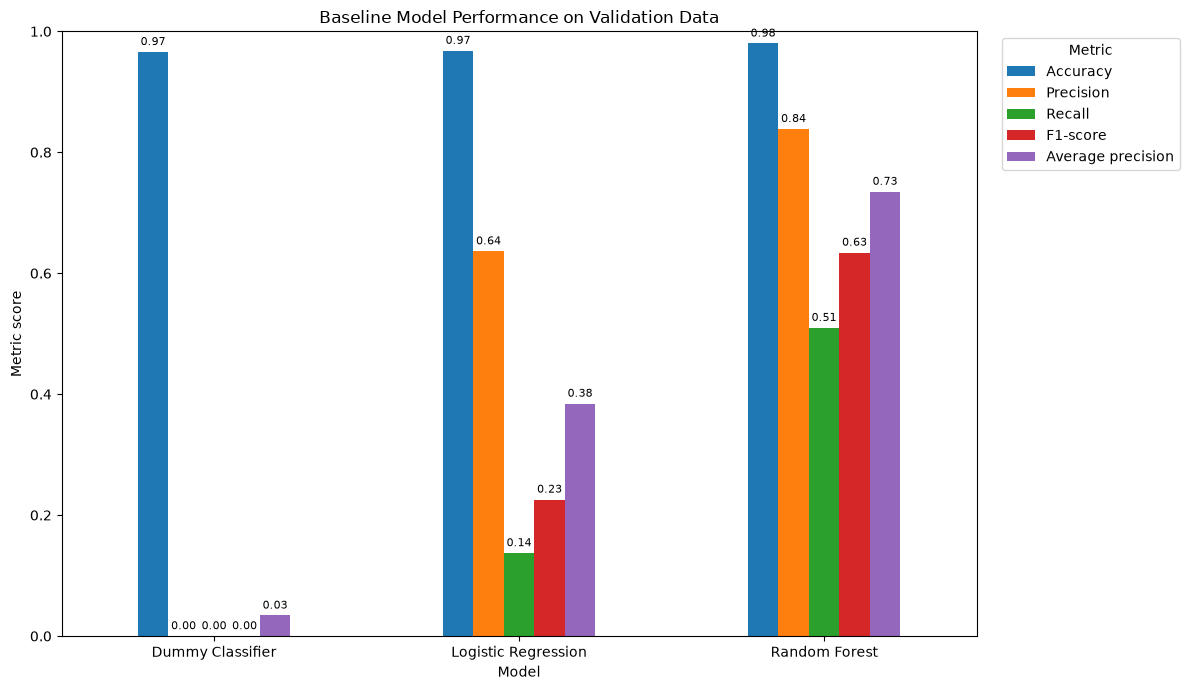

Figure saved to: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\figures\baseline_model_comparison.png


In [14]:
import matplotlib.pyplot as plt

# Create a grouped bar chart directly from the results table
ax = baseline_results.plot(
    kind="bar",
    figsize=(12, 7),
    ylim=(0, 1),
    rot=0
)

# Add numerical values above the bars
for bar_group in ax.containers:
    ax.bar_label(
        bar_group,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

ax.set_title(
    "Baseline Model Performance on Validation Data"
)

ax.set_xlabel("Model")
ax.set_ylabel("Metric score")
ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save the graph
baseline_figure_path = (
    project_root
    / "figures"
    / "baseline_model_comparison.png"
)

plt.savefig(
    baseline_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {baseline_figure_path}")

## 8. Baseline Confusion Matrices

The confusion matrices show the exact correct predictions, false alarms, missed failures, and detected failures produced by each baseline model.

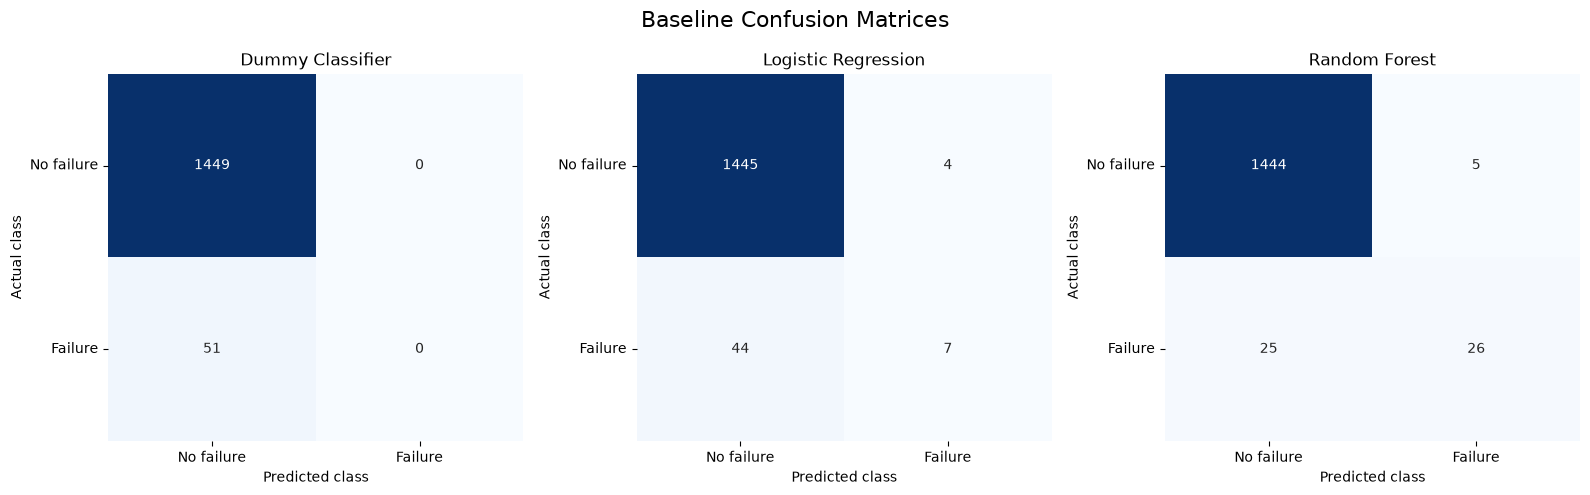

Figure saved to: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\figures\baseline_confusion_matrices.png


In [15]:
import seaborn as sns

# Store the matrices and model names in matching order
confusion_matrices = [
    dummy_confusion_matrix,
    logistic_confusion_matrix,
    random_forest_confusion_matrix
]

model_names = [
    "Dummy Classifier",
    "Logistic Regression",
    "Random Forest"
]

# Create three graph positions
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

# Draw one confusion matrix for each model
for axis, matrix, model_name in zip(
    axes,
    confusion_matrices,
    model_names
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis
    )

    axis.set_title(model_name)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
    axis.set_xticklabels(
        ["No failure", "Failure"]
    )
    axis.set_yticklabels(
        ["No failure", "Failure"],
        rotation=0
    )

plt.suptitle(
    "Baseline Confusion Matrices",
    fontsize=16
)

plt.tight_layout()

# Save the figure
confusion_figure_path = (
    project_root
    / "figures"
    / "baseline_confusion_matrices.png"
)

plt.savefig(
    confusion_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {confusion_figure_path}")

## 9. Class-Weighted Models

Class weighting is applied to increase the training importance of rare failure records. The objective is to improve recall while measuring the resulting precision and false-alarm trade-off.

In [16]:
from src.evaluation import evaluate_classifier

# Create class-weighted Logistic Regression
weighted_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

weighted_logistic_model.fit(
    X_train_processed,
    y_train
)

# Evaluate weighted Logistic Regression
(
    weighted_logistic_metrics,
    weighted_logistic_matrix,
    weighted_logistic_predictions,
    weighted_logistic_probabilities
) = evaluate_classifier(
    weighted_logistic_model,
    X_validation_processed,
    y_validation
)


# Create class-weighted Random Forest
weighted_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weighted_forest_model.fit(
    X_train_tree,
    y_train
)

# Evaluate weighted Random Forest
(
    weighted_forest_metrics,
    weighted_forest_matrix,
    weighted_forest_predictions,
    weighted_forest_probabilities
) = evaluate_classifier(
    weighted_forest_model,
    X_validation_tree,
    y_validation
)


# Display weighted-model results
weighted_results = pd.DataFrame(
    [
        weighted_logistic_metrics,
        weighted_forest_metrics
    ],
    index=[
        "Weighted Logistic Regression",
        "Weighted Random Forest"
    ]
)

print("Weighted model metrics:")
display(weighted_results.round(4))

print("\nWeighted Logistic Regression confusion matrix:")
print(weighted_logistic_matrix)

print("\nWeighted Random Forest confusion matrix:")
print(weighted_forest_matrix)

Weighted model metrics:


,Accuracy,Precision,Recall,F1-score,Average precision
Weighted Logistic Regression,0.8347,0.1365,0.7255,0.2298,0.3829
Weighted Random Forest,0.9753,0.6522,0.5882,0.6186,0.6756



Weighted Logistic Regression confusion matrix:
[[1215  234]
 [  14   37]]

Weighted Random Forest confusion matrix:
[[1433   16]
 [  21   30]]


## 10. Random Forest Decision-Threshold Analysis

Different decision thresholds are evaluated using the unweighted Random Forest probabilities. The objective is to improve failure recall while controlling false alarms and precision loss.

In [17]:
import numpy as np

# Thresholds from 0.05 to 0.50
thresholds = np.arange(
    0.05,
    0.55,
    0.05
)

threshold_records = []

for threshold in thresholds:

    # Convert probabilities into class decisions
    threshold_predictions = (
        random_forest_probabilities >= threshold
    ).astype(int)

    # Calculate the confusion matrix
    matrix = confusion_matrix(
        y_validation,
        threshold_predictions
    )

    tn, fp, fn, tp = matrix.ravel()

    # Store metrics for this threshold
    threshold_records.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            threshold_predictions
        ),
        "F1-score": f1_score(
            y_validation,
            threshold_predictions
        ),
        "False positives": fp,
        "False negatives": fn,
        "True positives": tp
    })

# Convert results into a table
threshold_results = pd.DataFrame(
    threshold_records
)

# Save the threshold experiment
threshold_results.to_csv(
    project_root
    / "results"
    / "random_forest_threshold_results.csv",
    index=False
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1-score,False positives,False negatives,True positives
0,0.05,0.2901,0.9216,0.4413,115,4,47
1,0.10,0.3866,0.9020,0.5412,73,5,46
2,0.15,0.4773,0.8235,0.6043,46,9,42
3,0.20,0.5694,0.8039,0.6667,31,10,41
4,0.25,0.6429,0.7059,0.6729,20,15,36
5,0.30,0.6731,0.6863,0.6796,17,16,35
6,0.35,0.7500,0.6471,0.6947,11,18,33
7,0.40,0.8158,0.6078,0.6966,7,20,31
8,0.45,0.8000,0.5490,0.6512,7,23,28
9,0.50,0.8125,0.5098,0.6265,6,25,26


## 11. Threshold Selection

A threshold of 0.20 is selected as the safety-oriented operating point because it achieves at least 80% validation recall with a manageable false-positive rate. A threshold of 0.40 is retained as the F1-optimal comparison point.

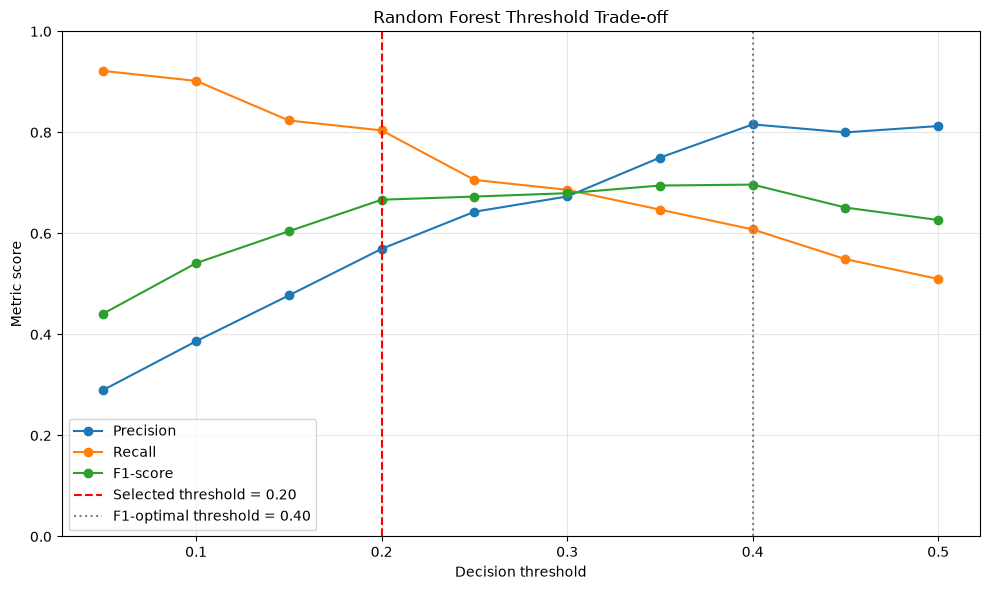

Selected threshold: 0.2
Figure saved to: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\figures\random_forest_threshold_tradeoff.png


In [18]:
# Formally record the selected threshold
selected_threshold = 0.20

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-score"],
    marker="o",
    label="F1-score"
)

# Mark the selected safety-oriented threshold
plt.axvline(
    selected_threshold,
    color="red",
    linestyle="--",
    label="Selected threshold = 0.20"
)

# Mark the highest-F1 threshold
plt.axvline(
    0.40,
    color="gray",
    linestyle=":",
    label="F1-optimal threshold = 0.40"
)

plt.title(
    "Random Forest Threshold Trade-off"
)

plt.xlabel("Decision threshold")
plt.ylabel("Metric score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

threshold_figure_path = (
    project_root
    / "figures"
    / "random_forest_threshold_tradeoff.png"
)

plt.savefig(
    threshold_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Selected threshold: {selected_threshold}")
print(f"Figure saved to: {threshold_figure_path}")

## 12. Final Test-Set Evaluation

The selected unweighted Random Forest with a fixed decision threshold of 0.20 is evaluated once on the untouched test set. No model or threshold changes are made using test results.

In [ ]:
# Apply the Random Forest preprocessing to the test set
X_test_tree = tree_preprocessor.transform(
    X_test
)

# Obtain test-set failure probabilities
test_probabilities = random_forest_model.predict_proba(
    X_test_tree
)[:, 1]

# Apply the threshold selected using validation data
test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

# Calculate correct final metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions
)

test_ap = average_precision_score(
    y_test,
    test_probabilities
)

test_matrix = confusion_matrix(
    y_test,
    test_predictions
)

# Create the corrected result table
final_test_results = pd.DataFrame(
    {
        "Accuracy": [test_accuracy],
        "Precision": [test_precision],
        "Recall": [test_recall],
        "F1-score": [test_f1],
        "Average precision": [test_ap],
        "Threshold": [selected_threshold]
    },
    index=["Selected Random Forest"]
)

# Overwrite the invalid CSV with correct results
final_test_results.to_csv(
    project_root
    / "results"
    / "final_test_metrics.csv"
)

print("Corrected final test results:")
display(final_test_results.round(4))

print("\nCorrected final test confusion matrix:")
print(test_matrix)

Corrected final test results:


,Accuracy,Precision,Recall,F1-score,Average precision,Threshold
Selected Random Forest,0.9727,0.5676,0.8235,0.672,0.7803,0.2



Corrected final test confusion matrix:
[[1417   32]
 [   9   42]]


: 

## Baseline Model Selection Summary

This notebook established the clean-data baseline for the machine-failure
prediction study.

Three main prediction approaches were considered:

- Dummy classifier
- Logistic Regression
- Random Forest

Because machine failures are rare, model selection was not based only on
accuracy. Precision, recall, F1-score, average precision, and confusion
matrices were also examined.

The Random Forest produced the strongest overall failure-detection
performance. Decision-threshold analysis on the validation set showed that
the default probability threshold of 0.50 was too conservative for the
predictive-maintenance objective.

A threshold of **0.20** was therefore selected using validation data.

On the untouched final test set, the selected Random Forest achieved:

- Accuracy: **97.27%**
- Precision: **56.76%**
- Recall: **82.35%**
- F1-score: **67.20%**
- Average Precision: **78.03%**

The final confusion matrix was:

| | Predicted Healthy | Predicted Failure |
|---|---:|---:|
| Actual Healthy | 1417 | 32 |
| Actual Failure | 9 | 42 |

Therefore, the model detected approximately **82% of machine failures**
while producing false alarms for only approximately **2.2% of healthy
machines**.

The similarity between validation and test performance suggests that the
selected decision threshold generalizes reasonably well to unseen clean
data.

This clean-data model will now serve as the reference system for the
robustness experiments. The next stage investigates how its performance
changes when sensor measurements are corrupted by noise, contain missing
values, or when less labelled training data is available.